In [221]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
from timeit import default_timer as timer
import matplotlib.pyplot as plt
device='cpu'

In [222]:
import kagglehub


model_path = kagglehub.dataset_download("hojjatk/mnist-dataset")

In [223]:
## Model 1
class LeNet5V10(nn.Module):
    def __init__(self):
        super().__init__()
        self.feature = nn.Sequential(
            #1
            nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1, padding=2),   # 28*28->32*32-->28*28
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2),  # 14*14

            #2
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1),  # 10*10
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2),  # 5*5

        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=16*5*5, out_features=120),
            nn.Tanh(),
            nn.Linear(in_features=120, out_features=84),
            nn.Tanh(),
            nn.Linear(in_features=84, out_features=10),
        )

    def forward(self, x):
           return F.log_softmax(self.classifier(self.feature(x)),dim=1)

In [224]:
## Model 2

class LeNet5V1(nn.Module):
  def __init__(self):
      super(LeNet5V1, self).__init__()
      self.conv1 = nn.Conv2d(1, 6, 5)
      self.bn1=nn.BatchNorm2d(6)
      self.relu1 = nn.ReLU()
      self.pool1 = nn.MaxPool2d(2)
      self.conv2 = nn.Conv2d(6, 16, 5)
      self.bn2=nn.BatchNorm2d(16)
      self.relu2 = nn.ReLU()
      self.pool2 = nn.MaxPool2d(2)
      self.fc1 = nn.Linear(256, 120)
      self.relu3 = nn.ReLU()
      self.fc2 = nn.Linear(120, 84)
      self.relu4 = nn.ReLU()
      self.fc3 = nn.Linear(84, 11)
      self.relu5 = nn.ReLU()

  def forward(self, x):
     fealist=[]
     y = self.conv1(x)
     fealist.append(y.clone().detach())
     y=self.bn1(y)
     y = self.relu1(y)
     y = self.pool1(y)
     y = self.conv2(y)
     y=self.bn2(y)
     fealist.append(y.clone().detach())
     y = self.relu2(y)
     y = self.pool2(y)
     y = y.view(y.shape[0], -1)
     y = self.fc1(y)
     y = self.relu3(y)
     y = self.fc2(y)
     y = self.relu4(y)
     y = self.fc3(y)
     y = self.relu5(y)
     y= F.log_softmax(y, dim=1)
     return y

In [225]:
## Model 3

class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.cn1 = nn.Conv2d(1, 16, 3, 1)
        self.cn2 = nn.Conv2d(16, 32, 3, 1)
        self.dp1 = nn.Dropout2d(0.10)
        self.dp2 = nn.Dropout2d(0.25)
        self.fc1 = nn.Linear(4608, 64) # 4608 is basically 12 X 12 X 32
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.cn1(x)
        x = F.relu(x)
        x = self.cn2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dp1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dp2(x)
        x = self.fc2(x)
        op = F.log_softmax(x, dim=1)
        return op

In [226]:
## Model 4

# Convolutional neural network (two convolutional layers)
class ConvNet2(nn.Module):
    def __init__(self, num_classes=10):
        super(ConvNet2, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.fc = nn.Linear(7*7*32, num_classes)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.reshape(out.size(0), -1)
        out = self.fc(out)
        out2 = F.log_softmax(out, dim=1)
        return out2

In [227]:
## Model 5

# Create CNN Model
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        # Convolution 1
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=0)
        self.relu1 = nn.ReLU()

        # Max pool 1
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)

        # Convolution 2
        self.cnn2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0)
        self.relu2 = nn.ReLU()

        # Max pool 2
        self.maxpool2 = nn.MaxPool2d(kernel_size=2)

        # Fully connected 1
        self.fc1 = nn.Linear(32 * 4 * 4, 10)

    def forward(self, x):
        # Convolution 1
        out = self.cnn1(x)
        out = self.relu1(out)

        # Max pool 1
        out = self.maxpool1(out)

        # Convolution 2
        out = self.cnn2(out)
        out = self.relu2(out)

        # Max pool 2
        out = self.maxpool2(out)

        # flatten
        out = out.view(out.size(0), -1)

        # Linear function (readout)
        out = self.fc1(out)
        out2=F.log_softmax(out, dim=1)
        return out2

In [228]:
## Model 6

class MLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()

        self.input_fc = nn.Linear(input_dim, 16)
        self.hidden_fc = nn.Linear(16, 16)
        self.hidden_fc = nn.Linear(16, 16)
        self.output_fc = nn.Linear(16, output_dim)

    def forward(self, x):
        # x = [batch size, height, width]
        batch_size = x.shape[0]
        x = x.view(batch_size, -1)
        # x = [batch size, height * width]
        h_1 = F.relu(self.input_fc(x))
        # h_1 = [batch size, 250]
        h_2 = F.relu(self.hidden_fc(h_1))
        # h_2 = [batch size, 100]
        y_pred = self.output_fc(h_2)
        # y_pred = [batch size, output dim]
        op = F.log_softmax(y_pred, dim=1)
        return op

In [229]:
def train(model, device, train_dataloader, optim, epoch):
    model.train()
    for b_i, (X, y) in enumerate(train_dataloader):
        X, y = X.to(device), y.to(device)
        optim.zero_grad()
        pred_prob = model(X)
        loss = F.nll_loss(pred_prob, y) # nll is the negative likelihood loss
        loss.backward()
        optim.step()
        if b_i % 200 == 0:
            print('epoch: {} [{}/{} ({:.0f}%)]\t training loss: {:.6f}'.format(
                epoch, b_i * len(X), len(train_dataloader.dataset),
                100. * b_i / len(train_dataloader), loss.item()))

In [230]:
def test(model, device, test_dataloader):
    model.eval()
    loss = 0
    success = 0
    with torch.inference_mode():
        for X, y in test_dataloader:
            X, y = X.to(device), y.to(device)
            pred_prob = model(X)
            loss += F.nll_loss(pred_prob, y, reduction='sum').item()  # loss summed across the batch
            pred = pred_prob.argmax(dim=1, keepdim=True)  # us argmax to get the most likely prediction
            success += pred.eq(y.view_as(pred)).sum().item()

    loss /= len(test_dataloader.dataset)

    print('\nTest dataset: Overall Loss: {:.4f}, Overall Accuracy: {}/{} ({:f}%)\n'.format(
        loss, success, len(test_dataloader.dataset),
        100. * success / len(test_dataloader.dataset)))

In [231]:
import torch
# The mean and standard deviation values are calculated as the mean of all pixel values of all images in the training dataset

train_transforms = transforms.Compose([
                            transforms.RandomRotation(1, fill=(0,)),
                            transforms.RandomCrop(28, padding=1),
                            transforms.ToTensor(),
                            transforms.Normalize(mean=[0.1302], std=[0.3069])])  ## train_X.mean()/256. and train_X.std()/256

train_dataloader = torch.utils.data.DataLoader(
    datasets.MNIST(model_path, train=True, download=True,
                   transform=train_transforms),
    batch_size=32, shuffle=True)

test_dataloader = torch.utils.data.DataLoader(
    datasets.MNIST(model_path, train=False,
                   transform=transforms.Compose([
                       transforms.ToTensor(),
                       transforms.Normalize((0.1302,), (0.3069,))  # train_X.mean()/256. and train_X.std()/256.
                   ])),
    batch_size=500, shuffle=True)

In [232]:
class_names = train_dataloader.dataset.classes # Access classes from the dataset object
class_names

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

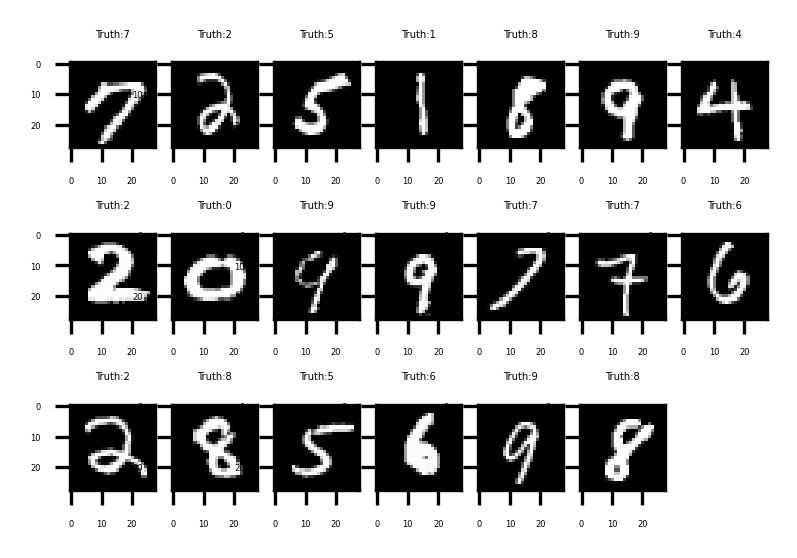

In [233]:
examples = enumerate(test_dataloader)
batch_idx, (example_data, example_targets) = next(examples)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(3,2.1),dpi=300)
plt.rcParams['font.size'] = 2
plt.axis('off')
for i in range(20):
  plt.subplot(3,7,i+1)
  plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
  plt.title("Truth:{}".format(example_targets[i]))

In [234]:
torch.manual_seed(0)

INPUT_DIM = 28 * 28
OUTPUT_DIM = 10

# model = MLP(INPUT_DIM, OUTPUT_DIM)
# model=ConvNet()
# model=ConvNet2()
model=CNNModel()
# model=LeNet5V1()

model.to(device)

optimizer = optim.Adadelta(model.parameters(), lr=0.5)

In [235]:
start=timer()
for epoch in range(1, 3):
    train(model, device, train_dataloader, optimizer, epoch)
    test(model, device, test_dataloader)

end=timer()

epoch: 1 [0/60000 (0%)]	 training loss: 2.370911
epoch: 1 [6400/60000 (11%)]	 training loss: 0.531616
epoch: 1 [12800/60000 (21%)]	 training loss: 0.065054
epoch: 1 [19200/60000 (32%)]	 training loss: 0.053171
epoch: 1 [25600/60000 (43%)]	 training loss: 0.075907
epoch: 1 [32000/60000 (53%)]	 training loss: 0.438607
epoch: 1 [38400/60000 (64%)]	 training loss: 0.172572
epoch: 1 [44800/60000 (75%)]	 training loss: 0.026619
epoch: 1 [51200/60000 (85%)]	 training loss: 0.125361
epoch: 1 [57600/60000 (96%)]	 training loss: 0.005377

Test dataset: Overall Loss: 0.0352, Overall Accuracy: 9886/10000 (98.860000%)

epoch: 2 [0/60000 (0%)]	 training loss: 0.020011
epoch: 2 [6400/60000 (11%)]	 training loss: 0.046454
epoch: 2 [12800/60000 (21%)]	 training loss: 0.045453
epoch: 2 [19200/60000 (32%)]	 training loss: 0.080712
epoch: 2 [25600/60000 (43%)]	 training loss: 0.020650
epoch: 2 [32000/60000 (53%)]	 training loss: 0.357969
epoch: 2 [38400/60000 (64%)]	 training loss: 0.407407
epoch: 2 [4480

In [236]:
# Importujemy tqdm na potrzeby wizualizacji postępu obliczeń
from tqdm.auto import tqdm

# Prognozowanie przy użyciu wytrenowanego modelu w celu ewaluacji jakości modelu
y_preds = []
test_data=[]

model.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Making predictions"):
    # dane na docelowe urządzenie
    X, y = X.to(device), y.to(device)
    # Propadacja w przód
    y_pred = model(X)
    y_preds.append(y_pred)
    test_data.append(y)
# Łączenie listy prognoz w tensor
y_pred_tensor = torch.cat(y_preds).data.max(1)[1]
print("Model: ",y_pred_tensor)
test_data=torch.cat(test_data)
print("Raw-test: ", test_data)

Making predictions: 100%|██████████| 20/20 [00:00<00:00, 28.62it/s]

Model:  tensor([0, 8, 9,  ..., 5, 0, 7])
Raw-test:  tensor([0, 1, 9,  ..., 5, 0, 7])


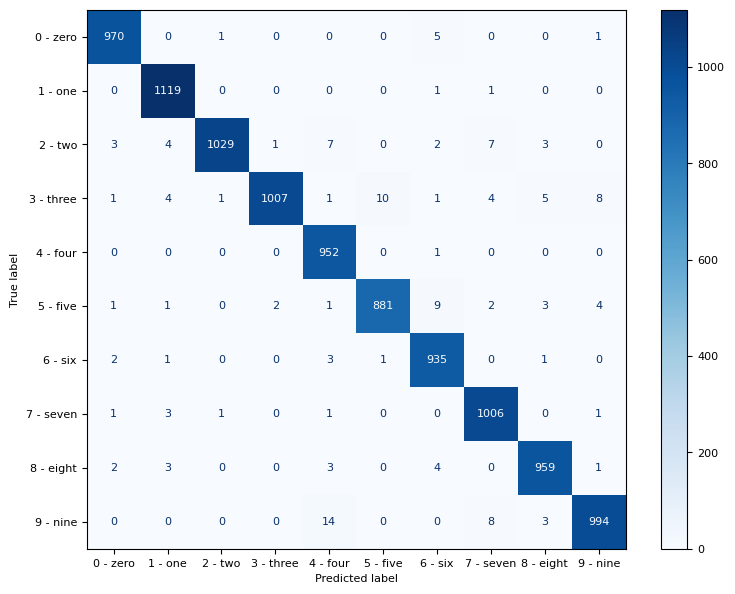

In [237]:
from sklearn import metrics

def plot_confusion_matrix(labels, pred_labels):
    plt.rcParams['font.size'] = 8
    fig = plt.figure(figsize=(9, 7),dpi=100)
    ax = fig.add_subplot(1, 1, 1)
    cm = metrics.confusion_matrix(labels, pred_labels)
    cm = metrics.ConfusionMatrixDisplay(cm, display_labels=class_names)
    cm.plot(values_format='d', cmap='Blues', ax=ax)

plot_confusion_matrix(y_pred_tensor.cpu().detach().numpy(), test_data.cpu().detach().numpy())

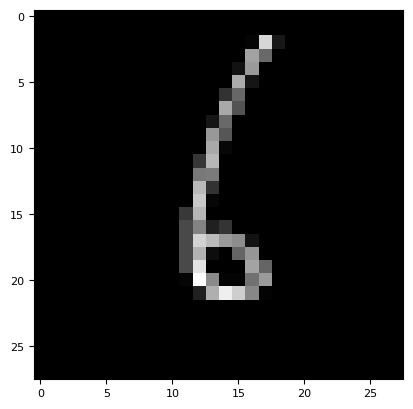

In [238]:
Example=50

test_samples = enumerate(test_dataloader)
b_i, (sample_data, sample_targets) = next(test_samples)

plt.imshow(sample_data[Example][0], cmap='gray', interpolation='none')
plt.show()

In [239]:
print(f"Model prediction is : {model(sample_data.to(device)).data.max(1)[1][Example]} ({class_names[model(sample_data.to(device)).data.max(1)[1][Example]]})")
print(f"Ground truth is : {sample_targets[Example]} ({class_names[sample_targets[Example].to(device).int()]})")

Model prediction is : 6 (6 - six)
Ground truth is : 6 (6 - six)


In [240]:
total_time = end - start
print(f"Train time on {device}: {total_time:.3f} seconds")

Train time on cpu: 60.156 seconds
